# The final approach, explained from zero

**What this notebook is.** Notebooks 00 to 03 were written as the work happened. Each
explains one layer, and each ends where the next round began. This notebook tells the
**whole final compiler** in one pass, from the problem to the submitted file, and it
adds the last idea of the project, the **shared branch state**, which none of the
earlier notebooks covers.

You can read it without the others. Every concept is rebuilt here briefly, in the
same way as notebooks 00 and 01: a small example you can hold in your head, a
picture, a knob to turn. Where an earlier notebook goes deeper, the section says
which one.

**The final compiler is called C1.** It is the accepted solver at the pivot tag
`pivot/luminal-phase2-third-round-20260926`, reviewed in
`results/phase2_structural_encoding/lead_resume_review_20260926/REVIEW.md`.

**Source of truth.** Nothing below re-implements the compiler. Every cell imports and
calls the real modules:

| module | what it owns |
|---|---|
| `.reference/machine.py` | the frozen machine and the validator (the challenge's, not ours) |
| `direct_contract.py`, `schema_index.py`, `direct_compiler.py` | the index-set representation and the first answer |
| `research/efficiency_search.py` | **R0**, the search that improves the first answer |
| `research/third_round_kernel.py` | the shared branch state |
| `research/third_round_candidate.py` | **C1** = R0 with the shared branch state inside |

**How to run it.** Choose the same kernel as notebooks 00 and 01, then run the cells
from top to bottom, one at a time. Nothing here writes to the repository. A few
cells time the compiler on your machine, so their seconds will differ slightly from
the ones printed in this file. Anything that depends on timing says so.

---

## 0. Setup

In [1]:
import collections
import hashlib
import json
import math
import statistics
import subprocess
import sys
import time
from pathlib import Path

ROOT = Path("/Users/alberto/Documents/projects/CausalBool/luminal-challenge").resolve()
for entry in (str(ROOT / ".reference"), str(ROOT), str(ROOT / "notebooks")):
    if entry not in sys.path:
        sys.path.insert(0, entry)

import machine                      # the frozen machine model and validator
import direct_contract as dc        # derived program facts
import schema_index as si           # the index-set representation: cubes and covers
import direct_compiler as dcomp     # the first answer, built from index queries

from research import structural_encoding as se        # decisions, ranks, J = C x S
from research import efficiency_search as r0          # R0: the accepted search before C1
from research import third_round_kernel as bs1        # the shared branch state
from research import third_round_candidate as c1      # C1: R0 + the shared branch state
from tests_direct import generate_programs as gp      # the program generator

import viz                          # every figure, shared with notebooks 00 to 03

EVIDENCE = ROOT / "results/phase2_structural_encoding"
RUN = EVIDENCE / "third_round_20260925_resume"
REVIEW = EVIDENCE / "lead_resume_review_20260926"
load = lambda path: json.loads(path.read_text())
sha = lambda path: hashlib.sha256(Path(path).read_bytes()).hexdigest()

for name, module in (("R0", r0), ("shared branch state", bs1), ("C1", c1)):
    print(f"{name:20} {Path(module.__file__).relative_to(ROOT)}   sha256 {sha(module.__file__)[:16]}")
print("\nC1 frozen for the confirmation as:",
      load(RUN / "CONFIRMATION_FREEZE.json")["sources"]["research/third_round_candidate.py"][:16])

R0                   research/efficiency_search.py   sha256 d0fcd441886cc5c3
shared branch state  research/third_round_kernel.py   sha256 77c373e1d4e6a328
C1                   research/third_round_candidate.py   sha256 b9697640e202c7cf

C1 frozen for the confirmation as: b9697640e202c7cf


The last two lines should match. The confirmation run froze C1's bytes before
measuring anything, and the file you are about to run is those same bytes.

---

# 1. The problem, in one page

*(Notebook 00 builds all of this slowly. Here it is compressed to what the rest of
this notebook needs.)*

A **program** says *what* to compute: load these numbers, add them, store the result.
The compiler must decide two things the program leaves open:

- **when** each operation is handed to the machine (its **issue cycle**), and
- **where** each intermediate value is kept (its **scratch address**).

The kitchen analogy of notebook 00 still fits exactly. The clock ticks; at each tick
you hand jobs to specialist cooks (the **engines**), each of whom can start only a
fixed number of jobs per tick (their **slots**). A job's result appears only some ticks
later (its **latency**). Every result waits on a numbered shelf (the **scratchpad**)
until the last job that needs it has read it.

Our running example is one of the eight public programs, `05_mixed_broadcast`.

In [2]:
program = machine.load_program(ROOT / ".reference/programs/05_mixed_broadcast.json")
facts = dc.derive(program)          # a read-only view: engines, latencies, who reads whom

print("engine slots per cycle:", machine.ENGINE_LIMITS, "\n")
print(f"{'op':>2}  {'opcode':8} {'engine':7} {'latency':>7}  reads -> writes")
for op in program["operations"]:
    i = op["id"]
    print(f"{i:>2}  {op['op']:8} {facts.engine[i]:7} {facts.latency[i]:>7}  "
          f"{op.get('args') or '-'} -> {op.get('dest') or op.get('buffer')}")

engine slots per cycle: {'load': 2, 'scalar': 2, 'vector': 2, 'store': 1, 'flow': 1} 

op  opcode   engine  latency  reads -> writes
 0  vload    load          4  - -> weights0
 1  load     load          3  - -> bias0
 2  load     load          3  - -> gate0
 3  splat    vector        1  ['bias0'] -> vbias
 4  splat    vector        1  ['gate0'] -> vgate
 5  vmul     vector        3  ['weights0', 'vgate'] -> scaled
 6  vadd     vector        1  ['scaled', 'vbias'] -> result
 7  vstore   store         1  ['result'] -> out


Eight operations. Some read scalars, some read eight-word vectors (the `v` opcodes),
and `splat` copies one scalar into all eight lanes of a vector.

## 1.1 The score, and the one number we minimise

The challenge scores a compilation by two counts:

- **C**, the number of cycles the schedule lasts;
- **S**, the scratch footprint, i.e. the highest shelf position used, plus one.

The official score compares both counts with the serial compiler's: it is the
geometric mean, over programs, of how many times smaller C and S are than serial's. All of our search minimises the single product **J = C × S**. Halving
either count halves J, and J cannot be improved on one count by silently paying on
the other.

The slowest legal compiler, the serial one, hands over one operation per cycle.
It is the yardstick the score is measured against.

serial compile:  C = 11, S = 42, J = 462


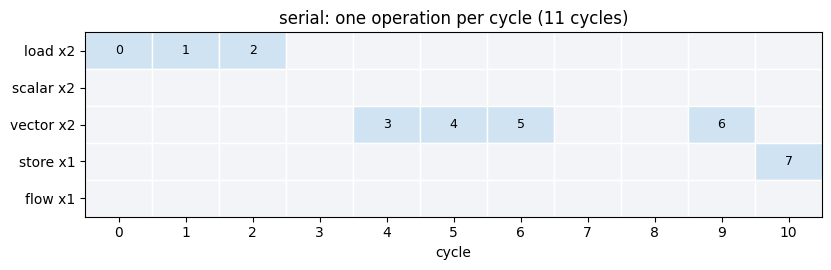

In [3]:
serial = machine.serial_compile(program)
C = machine.check_compilation(program, serial)       # the validator returns the cycle count
S = machine.scratch_footprint(program, serial)
print(f"serial compile:  C = {C}, S = {S}, J = {C * S}")
viz.show_timeline(serial["bundles"], f"serial: one operation per cycle ({C} cycles)")

Each column is a cycle, each row an engine; a blue cell is an operation issued
there. Nearly every slot is empty. The rest of the notebook is about filling this
grid tightly, **and** keeping the shelf short, **and** proving each step legal.

---

# 2. The whole final approach on one page

C1 answers the problem in two phases. The first gives a good answer quickly. The
second improves it by reopening a few decisions at a time and searching them
exactly.

| step | what happens | the idea it rests on | § |
|---|---|---|---|
| 1 | **First answer.** Every issue cycle and every address is the smallest member of a set described by index cubes | index-set representation (notebook 01) | 3 |
| 2 | **Choose what to reopen.** A catalogue of *windows*: groups of related operations whose decisions may change | large neighbourhood search (Shaw 1998) | 4 |
| 3 | **Say what "better" must look like.** Two integer caps derived from J | strict-product domain | 5 |
| 4 | **Write the question.** Each reopened decision gets a short ordered list of options; option 0 is the current answer | the structural codec (notebook 02) | 6 |
| 5 | **Delete impossible options early**, each deletion with a checkable reason | sound propagation with certificates | 7 |
| 6 | **Search the question exactly**, depth-first, pruning with a lower bound | branch and bound | 8 |
| 7 | **Keep the first strict improvement**, validate it with the challenge's own checker, and start again from it | first-improvement local search | 9 |
| 8 | **Do not redo work a child already inherited** from its parent | the shared branch state (new in C1) | 10 |

Steps 1 to 7 are **R0**, the accepted solver before the last round. Step 8 is the
only difference between R0 and C1. It changes **how fast** the search runs, never
**what** it decides. Most of this notebook is about proving that sentence.

---

# 3. Step 1: the first answer, from index queries

*(Notebook 01 explains this in full: cubes in §2, covers of ranges in §4, the "when"
query in §5 and the "where" query in §6.)*

## 3.1 The one idea: a set described by two numbers

Recall the eight boxes of notebook 01. Three yes/no questions (x0, x1, x2) name one
box. Allow a third answer, `*` for "either", and a string such as `x0..x2:*1*`
describes a **set** of boxes, here {2, 3, 6, 7}. The computer never stores the
set. It stores two integers: the **anchor** (the answers that are 1) and the
**free mask** (the positions that are `*`).

label     : x0..x2:*1*
anchor    : 2   free mask: 5
members   : [2, 3, 6, 7]
smallest  : 2  <- every * may be 0, so the anchor is the smallest member


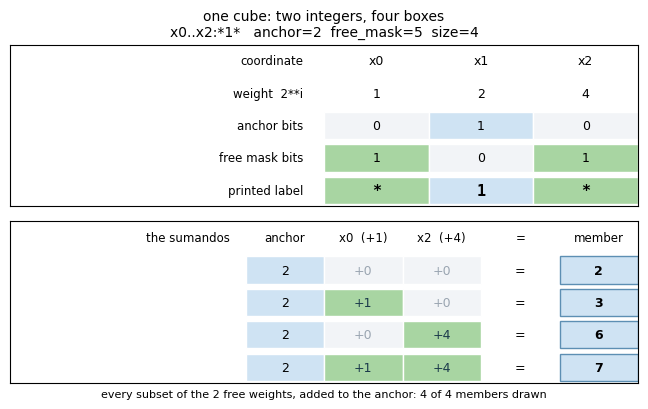

In [4]:
cube = si.Cube(3, anchor=0b010, free_mask=0b101)
print("label     :", cube.label())
print("anchor    :", cube.anchor, "  free mask:", cube.free_mask)
print("members   :", sorted(cube.members()))
print("smallest  :", cube.anchor, " <- every * may be 0, so the anchor is the smallest member")
viz.show_cube_anatomy(cube, "one cube: two integers, four boxes")

Read the boxes as **cycles** instead, and the same object answers "which cycles
may this operation use?". A range of cycles is a handful of such cubes, called a
**cover**. Removing the cycles where the engine is already full is a set
difference. The chosen cycle is the smallest member of what survives.

Here is that query for one real operation. The numbers are chosen to show the
effect: cycles 3 to 11 are allowed, and cycles 4 and 5 are full.

cycles 3..11 as a cover: ['x0..x3:1100', 'x0..x3:**10', 'x0..x3:**01']
after removing 4 and 5 : ['x0..x3:1100', 'x0..x3:1110', 'x0..x3:0110', 'x0..x3:**01']
chosen cycle           : 3


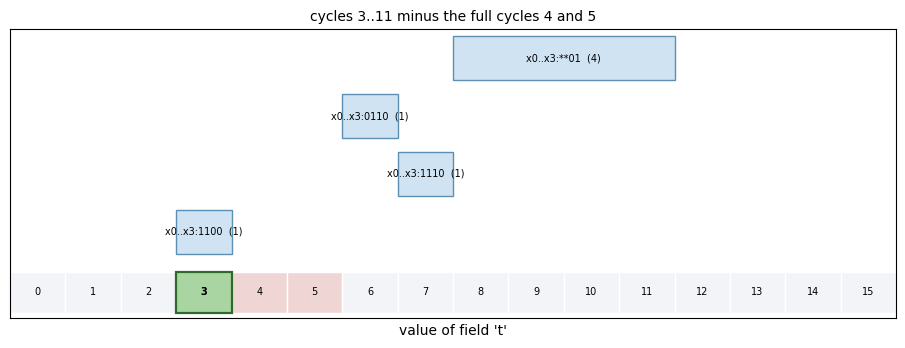

In [5]:
field = si.Field(name="t", offset=0, width=4)            # a 4-bit cycle coordinate
cover = si.interval(field, lo=3, hi=11, n=4)             # "any cycle from 3 to 11"
print("cycles 3..11 as a cover:", [c.label() for c in cover])

full = [si.Cube(4, field.encode(cycle), 0) for cycle in (4, 5)]   # engine already full here
survivors = list(cover)
for blocked in full:
    survivors = [piece for c in survivors for piece in si.difference(c, blocked)]
print("after removing 4 and 5 :", [c.label() for c in survivors])
print("chosen cycle           :", field.decode(si.min_member(survivors)))

viz.show_cover_blocks(survivors, field, lo=0, hi=15,
                      title="cycles 3..11 minus the full cycles 4 and 5", excluded=[4, 5],
                      chosen=field.decode(si.min_member(survivors)))

**Turn the knob.** Change `(4, 5)` to `(3, 4, 5)` and run the cell again. The chosen
cycle moves to 6, and the cover changes shape, but it never lists the cycles one by
one. The same operations on an 8-bit address coordinate choose scratch addresses,
with vectors additionally required to start on a multiple of eight.

## 3.2 The first answer for the running example

`direct_compiler` applies that query to every operation in order (the "when"), then
to every value (the "where"). The result is a complete, legal compilation.

first answer:  C = 10, S = 24, J = 240   (serial J was 462)
index queries used: {'queries': 15, 'largest_cover': 4, 'intersections': 33}


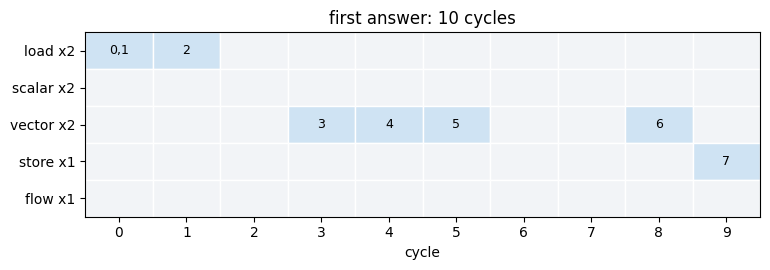

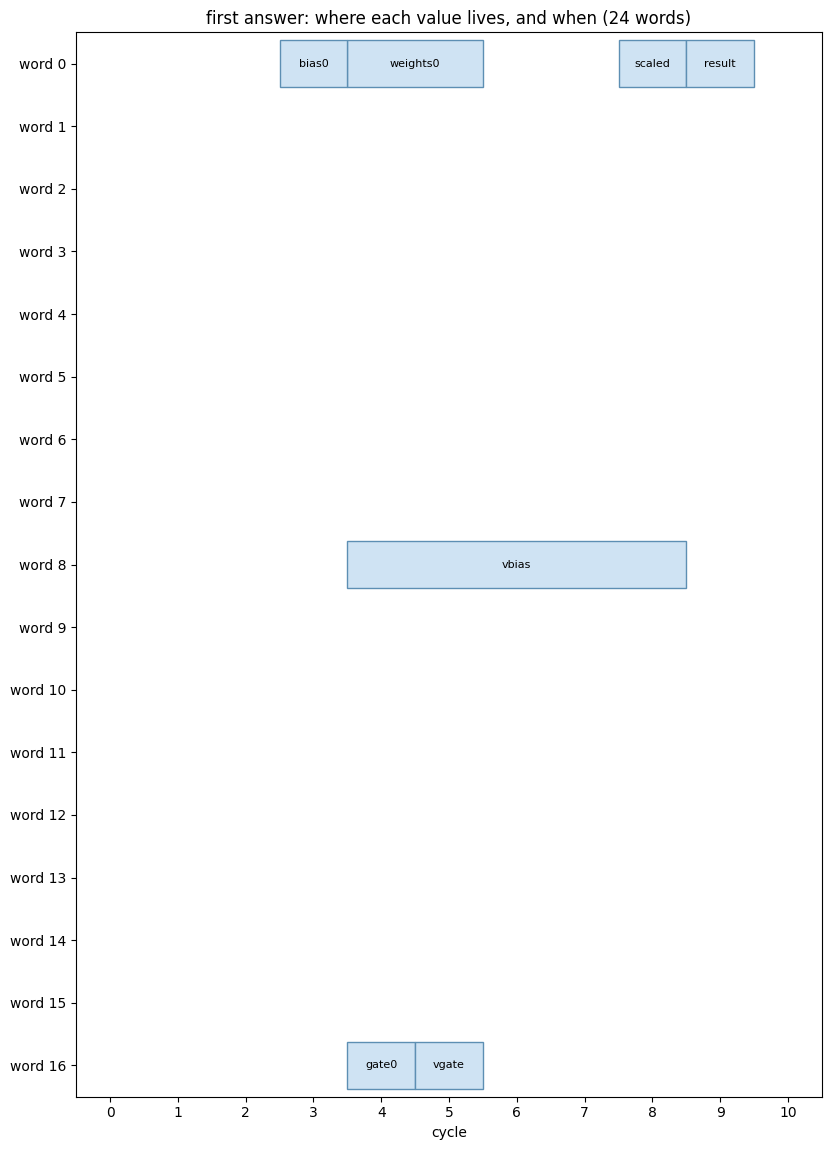

In [6]:
first, report = dcomp.compile_with_report(program, dcomp.DEFAULT_LIMITS, optimise=False)
times0 = se.issue_cycles_of(program, first["bundles"])     # op -> issue cycle
addresses0 = dict(first["scratch"])                        # value -> scratch address
C0, S0, J0 = se.objective(facts, times0, addresses0)
print(f"first answer:  C = {C0}, S = {S0}, J = {J0}   (serial J was {C * S})")
print("index queries used:", report["bootstrap"]["queries"])
viz.show_timeline(first["bundles"], f"first answer: {C0} cycles")
viz.show_lifetimes(facts, addresses0, dc.lifetimes(facts, times0), C0 + 1,
                   f"first answer: where each value lives, and when ({S0} words)")

The schedule is now tight, but the shelf is not: each vector occupies a block of
eight words, and blocks are placed greedily, one value at a time. Nothing in the
first answer ever **revisits** a decision. That is what the rest of the compiler
does. From here on, the current best compilation is called the **incumbent**.

---

# 4. Step 2: choose what to reopen

Reopening every decision at once is hopeless: the number of combinations grows
exponentially. Reopening one at a time finds nothing, because good changes usually
move several operations together. The compromise is Shaw's **large neighbourhood
search**: release a *group of related* decisions, keep everything else fixed, and
solve the group exactly.

A released group is a **window** of operations, each allowed to move by up to a
**radius** of cycles. The catalogue mixes five kinds of window:

- small windows of four operations, radius 2 (the original Phase 1 moves);
- the *k* latest-issued operations, which decide **C**;
- the *k* operations around the memory peak, which decide **S**;
- contiguous blocks of *k*;
- the whole program, when it has at most 16 operations.

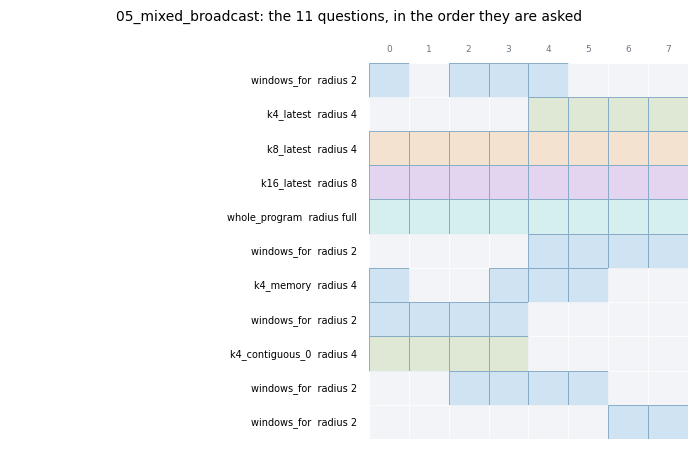

In [7]:
catalogue = r0.build_catalog(facts, times0, addresses0)
viz.show_window_catalog(
    [(f"{e['policy']}  radius {e['radius']}", e["window"]) for e in catalogue],
    facts.count, f"05_mixed_broadcast: the {len(catalogue)} questions, in the order they are asked")

A filled cell is an operation that question may move. Notice the third row: the
`k8_latest` window releases all eight operations at radius 4. Notebook 03 §8.3
showed, with a factorial experiment, that this catalogue is the part of the search
that earns the improvement.

---

# 5. Step 3: what "better" must look like

A question is only worth asking if an answer could beat the incumbent. For a window,
everything outside it is fixed, and that alone gives lower bounds for any answer:
**L_C** for the cycles and **L_S** for the scratch. A strict improvement needs
C × S ≤ J₀ − 1. Since S ≥ L_S and C ≥ L_C, two integer ceilings follow:

  **C ≤ C_cap = ⌊(J₀ − 1) / L_S⌋   and   S ≤ S_cap = ⌊(J₀ − 1) / L_C⌋**

So every strict improvement lies in a known box, and the search may be confined to
it without losing any. If a cap falls below its lower bound, the window is proved to
contain no improvement, and the question is answered without searching at all.

J0    : 240
LC    : 9
LS    : 8
Ccap  : 17
Scap  : 26
status: OK

C_cap = floor((240 - 1) / 8) = 29, then clipped to the program's horizon of 17 cycles
S_cap = floor((240 - 1) / 9) = 26


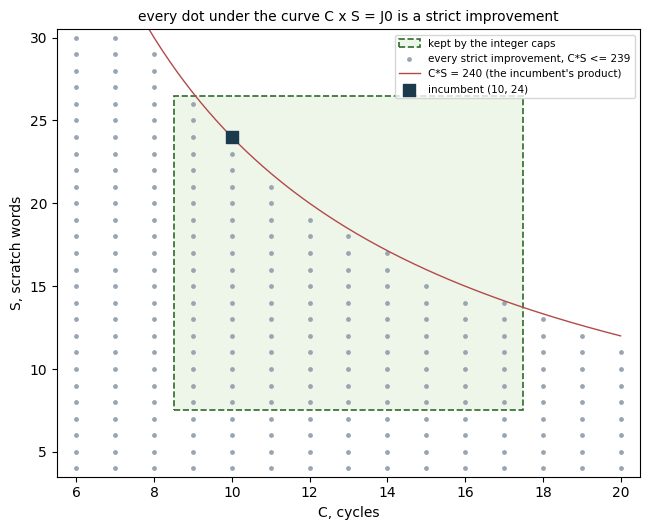

In [8]:
entry = next(e for e in catalogue if e["policy"] == "k8_latest")
caps = r0.product_caps(facts, times0, addresses0, entry["window"])
for key in ("J0", "LC", "LS", "Ccap", "Scap", "status"):
    print(f"{key:6}: {caps[key]}")
print(f"\nC_cap = floor(({caps['J0']} - 1) / {caps['LS']}) = {(caps['J0'] - 1) // caps['LS']}"
      f", then clipped to the program's horizon of {facts.horizon} cycles")
print(f"S_cap = floor(({caps['J0']} - 1) / {caps['LC']}) = {(caps['J0'] - 1) // caps['LC']}")
viz.show_objective_plane((C0, S0), "every dot under the curve C x S = J0 is a strict improvement",
                         caps=caps, c_range=(6, 20), s_range=(4, 30))

The green box is the region the question searches. Any dot in it would be accepted
if it turned out to be legal. Whether it is legal is decided by the next steps.

---

# 6. Step 4: write the question as a list of choices

Inside the window, every released operation gets a short list of candidate issue
cycles (its **time domain**), and later every released value a list of candidate
addresses. The order of each list matters: **option 0 is always the incumbent's own
choice**, followed by the others. So the path of all zeros reproduces the incumbent,
and every other path is a specific set of disagreements with it. *(Notebook 02 builds
this encoding and proves it decodes uniquely.)*

In [9]:
record = r0.product_record("k8_latest", program, facts, times0, addresses0,
                           entry["window"], entry["radius"], caps)
question = se.Domain.from_record(record)            # the question, as the search sees it
D_declared = {op: tuple(question.time_domains[op]) for op in question.selected_operations}

print(f"{'op':>3}  {'incumbent':>9}  declared time domain")
for op, values in D_declared.items():
    print(f"{op:>3}  {times0[op]:>9}  {values}")
combos = math.prod(len(v) for v in D_declared.values())
print(f"\n{combos:,} time combinations before any reasoning, and addresses come on top")

 op  incumbent  declared time domain
  0          0  (0, 1, 2, 3, 4)
  1          0  (0, 1, 2, 3, 4)
  2          1  (0, 1, 2, 3, 4, 5)
  3          3  (0, 1, 2, 3, 4, 5, 6, 7)
  4          4  (0, 1, 2, 3, 4, 5, 6, 7, 8)
  5          5  (1, 2, 3, 4, 5, 6, 7, 8, 9)
  6          8  (4, 5, 6, 7, 8, 9, 10, 11, 12)
  7          9  (5, 6, 7, 8, 9, 10, 11, 12, 13)

7,873,200 time combinations before any reasoning, and addresses come on top


---

# 7. Step 5: delete impossible options, with a reason for each

Most of those combinations are illegal for reasons that can be seen *before*
searching. Two rules do almost all of the work in the time phase:

1. **Precedence.** If operation *v* reads *u*'s result and *u* has latency ℓ, then
   t_v ≥ t_u + ℓ. So *v* cannot be earlier than min(D_u) + ℓ (certificate `PL`), and
   *u* cannot be later than max(D_v) − ℓ (`PU`).
2. **Engine capacity.** Once an operation's domain has shrunk to a single cycle, it
   occupies a slot there. A cycle whose slots are all occupied is removed from every
   other operation on that engine (`EF`); too many occupants proves the branch
   impossible (`EO`).

The rules are applied repeatedly until nothing changes (a **fixed point**), because
one deletion can enable another. Every deletion emits a **certificate**: a small
tuple that anyone holding the program can check in one line. Here is the root of our
question.

certificate ('PL', 0, 5, 4, 0, (1, 2, 3))
certificate ('PL', 1, 3, 3, 0, (0, 1, 2))
certificate ('PL', 2, 4, 3, 0, (0, 1, 2))
certificate ('PL', 5, 6, 3, 4, (4, 5, 6))
certificate ('PL', 6, 7, 1, 7, (5, 6, 7))


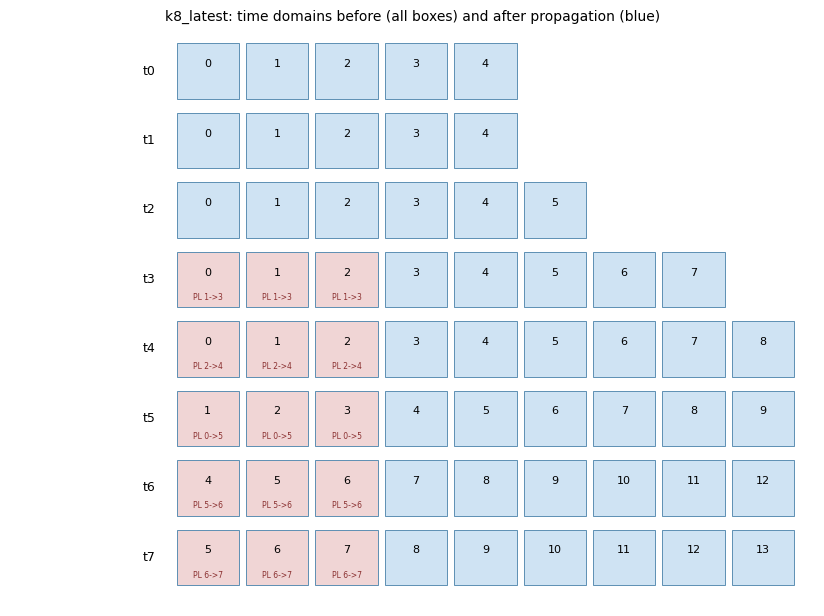

combinations: 7,873,200 -> 972,000


In [10]:
stats = r0.PropagationStats(keep=True)                # keep=True retains every certificate
propagation = r0.Propagation(question, stats)
D_root = propagation.times_fixpoint(D_declared)

reasons = collections.defaultdict(dict)
for certificate in stats.certificates:
    print("certificate", certificate)
    if certificate[0] in ("PU", "PL"):
        rule, u, v, lag, bound, removed = certificate
        for value in removed:
            reasons[u if rule == "PU" else v][value] = f"{rule} {u}->{v}"
viz.show_domain_filtering(
    [(f"t{op}", D_declared[op], D_root[op], reasons[op]) for op in D_declared],
    "k8_latest: time domains before (all boxes) and after propagation (blue)")
print(f"combinations: {combos:,} -> {math.prod(len(v) for v in D_root.values()):,}")

Read one certificate aloud, for example a `PL` line: *operation v reads operation u,
with lag ℓ; u cannot issue before min(D_u), so v cannot issue before min(D_u) + ℓ;
these cycles are removed*. Nothing is removed without a stated reason, and the
soundness of all four rules was tested against exhaustive enumeration (notebook 03
§4).

---

# 8. Step 6: search the question exactly

What propagation cannot rule out, the search decides. It is a **depth-first
search**. Take the first operation whose domain still has several cycles, try each
cycle in turn, propagate again, and go deeper. A partial choice is a **node**, and
the nodes it leads to are its **children**. A node is abandoned (**pruned**) when a
lower bound on J for everything below it is already no better than the best known.

One step of that search, taken by hand. Operation 0 is the vector load of
`weights0`, and the incumbent issues it at cycle 0. Delay it to cycle 2 and
propagate: everything that waits for `weights0` has to move too.

decision: operation 0 issues at cycle 2

certificate ('PL', 0, 5, 4, 2, (4, 5))
certificate ('PL', 5, 6, 3, 6, (7, 8))
certificate ('PL', 6, 7, 1, 9, (8, 9))


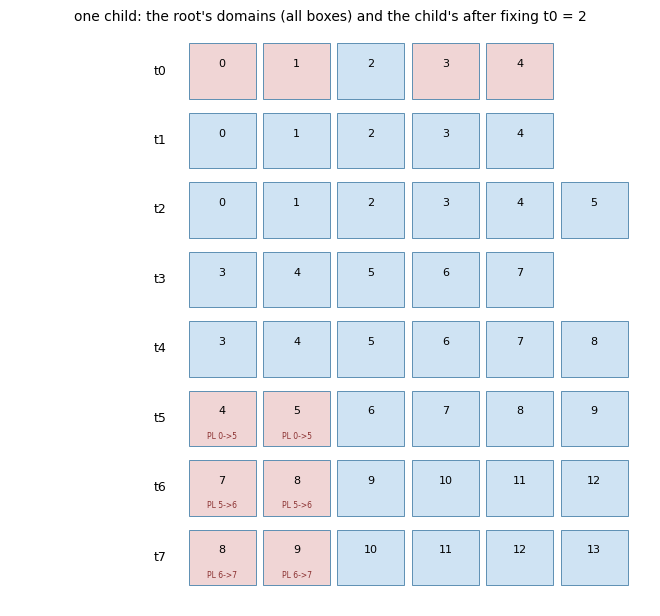

In [11]:
op, value = 0, 2                      # turn the knob: try other operations and cycles
child_stats = r0.PropagationStats(keep=True)
child_prop = r0.Propagation(question, child_stats)
fixed = dict(D_root)
fixed[op] = (value,)
D_child = child_prop.times_fixpoint(fixed)

print(f"decision: operation {op} issues at cycle {value}\n")
child_reasons = collections.defaultdict(dict)
for certificate in child_stats.certificates:
    print("certificate", certificate)
    if certificate[0] in ("PU", "PL"):
        rule, u, v, lag, bound, removed = certificate
        for x in removed:
            child_reasons[u if rule == "PU" else v][x] = f"{rule} {u}->{v}"
    elif certificate[0] == "EF":
        _, engine, cycle, o, limit = certificate
        child_reasons[o][cycle] = "EF"
viz.show_domain_filtering(
    [(f"t{o}", D_root[o], D_child[o], child_reasons[o]) for o in D_root],
    f"one child: the root's domains (all boxes) and the child's after fixing t{op} = {value}")

The red boxes in row `t0` are simply the decision itself: operation 0 is now at
cycle 2 and nowhere else. The other red boxes each carry the certificate that
removed them.

Look at which rows changed. The decision touched one operation, and propagation
spread the consequence to a few others; **most rows are identical to the parent's**.
Keep that picture in mind: it is the whole motivation for step 8.

---

# 9. Step 7: the controller, and one whole compilation

The pieces above answer one question. The **controller** decides which questions to
ask and when:

- It keeps up to **8 questions open at once** and gives each a short turn, a **slice**
  of at most 2 ms or 2,048 nodes, round-robin. One hard question therefore cannot
  consume the whole budget.
- The **first** question to find a strict improvement wins. Its answer is validated by
  the challenge's own checker, becomes the new incumbent, and a new **epoch** begins
  with a fresh catalogue built around it.
- The run ends when a whole epoch finds nothing (`pass_complete`), or when a limit is
  reached.

For explanation and testing, the controller can run on a **logical clock** that
never advances. Slices then end only by node count, and a compilation is limited by
a fixed number of nodes rather than by seconds. With a fixed clock the run is
fully deterministic, which §10 relies on.

In [12]:
class LogicalClock:
    '''A clock that never advances: slices end by node count only.'''
    def __call__(self):
        return 0.0

def run(module, program, facts, times, addresses, nodes=10_000, trace=None):
    '''One complete search, as the fixed-work measurements ran it.'''
    stats = module.PropagationStats()
    started = time.perf_counter()
    best_t, best_a, record = module.multiscale_optimise(
        program, facts, times, addresses, budget_seconds=0.1, node_ceiling=nodes,
        validation_ceiling=100_000, slice_nodes=2048, clock=LogicalClock(), stats=stats,
        trace=trace, catalog="a4", traversal="dfs")
    return best_t, best_a, record, time.perf_counter() - started

best_t, best_a, record, seconds = run(r0, program, facts, times0, addresses0)
print(f"R0 on 05_mixed_broadcast: {record['epochs']} epochs, {record['aggregate']['nodes']:,} nodes, "
      f"stopped: {record['stopped_because']}\n")
path = [(C0, S0)]
for step in record["improvements"]:
    print(f"epoch {step['epoch']}: {step['from_CS']} -> {step['to_CS']}   "
          f"found by {step['policy']} (radius {step['radius']}), window {step['window']}")
    path.append(tuple(step["to_CS"]))
C1_, S1_, J1_ = se.objective(facts, best_t, best_a)
print(f"\nfinal: C = {C1_}, S = {S1_}, J = {J1_}   (first answer {J0}, serial {C * S})")

R0 on 05_mixed_broadcast: 4 epochs, 5,476 nodes, stopped: pass_complete

epoch 1: [10, 24] -> [10, 17]   found by k8_latest (radius 4), window [0, 1, 2, 3, 4, 5, 6, 7]
epoch 2: [10, 17] -> [9, 17]   found by k8_latest (radius 4), window [0, 1, 2, 3, 4, 5, 6, 7]
epoch 3: [9, 17] -> [9, 16]   found by windows_for (radius 2), window [1, 2, 3, 4]

final: C = 9, S = 16, J = 144   (first answer 240, serial 462)


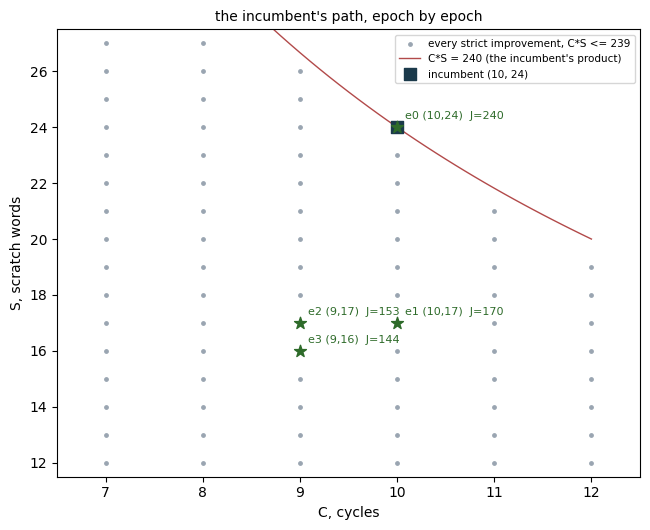

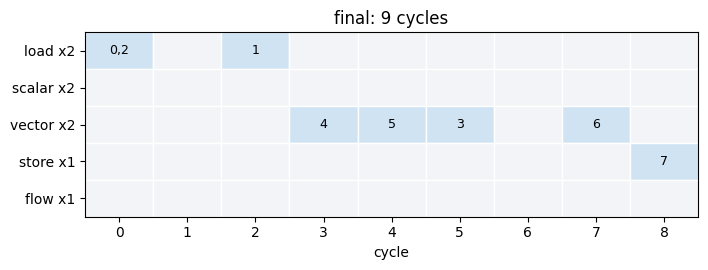

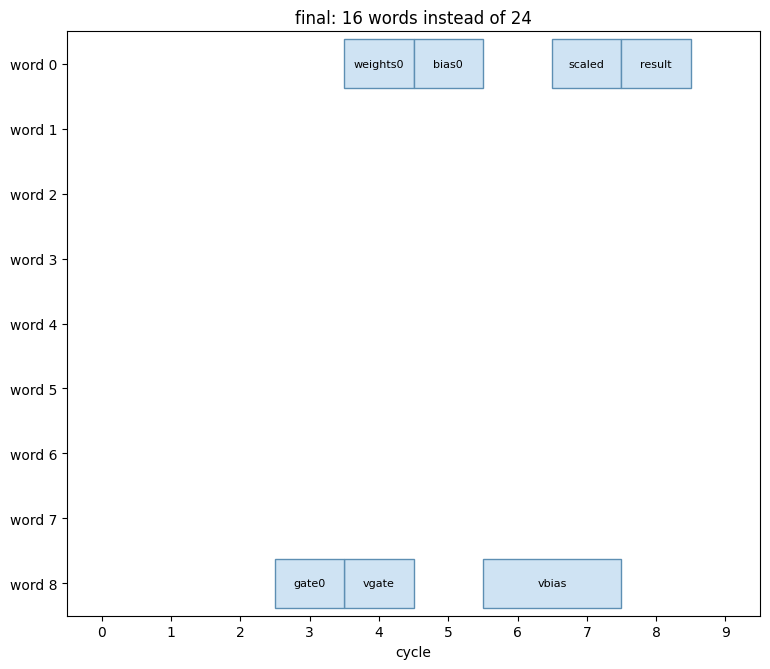

In [13]:
viz.show_objective_plane((C0, S0), "the incumbent's path, epoch by epoch",
                         points=[(f"e{i}", p) for i, p in enumerate(path)],
                         c_range=(7, 12), s_range=(12, 27))
final = dc.compilation(facts, best_t, best_a)
assert machine.check_compilation(program, final) == C1_       # the challenge's validator agrees
for case in program["cases"]:
    machine.check_case(program, final, case)                   # and every test case computes correctly
viz.show_timeline(final["bundles"], f"final: {C1_} cycles")
viz.show_lifetimes(facts, best_a, dc.lifetimes(facts, best_t), C1_ + 1,
                   f"final: {S1_} words instead of {S0}")

Read the path. The first epoch kept every cycle and cut the shelf by seven words,
through the large `k8_latest` window that releases all eight operations. The second
epoch, through the same window, saved a cycle. The third, through an ordinary
four-operation window, saved one more word. That window had nothing to offer from
the first answer: the large move opened the way, and a small one finished it.

---

# 10. Step 8: the last idea, the shared branch state

## 10.1 The waste

Go back to the picture at the end of §8. A child differs from its parent by **one
decision**. Yet R0 builds the child by copying the parent's domains and running the
whole fixed point again: it re-checks **every** precedence edge, recounts **every**
occupied slot and recomputes the memory bound from nothing. Almost all of that
re-derives facts the parent had already established. The round-2 profile in notebook
03 §8.4 measured the consequence: with the large catalogue, propagation was about
three-quarters of the compile time.

In the kitchen: you moved one job to a different tick. You do not need to re-read the
whole recipe book. You only need to re-check the recipes that mention that job, and
then the ones that mention whatever those changed.

## 10.2 The idea

Each search node keeps an **immutable branch state**: its domains plus the facts
derived from them (which cycles are full, which values must be alive when, the
current memory peak). Children read it and never modify it. A child applies its one
decision and records a **change record**: which domains lost their smallest or
largest value, and which became single cycles. Each rule then re-examines **only
what the change can reach**:

| rule | when must it look again? |
|---|---|
| precedence (u → v, lag ℓ) | only if max(D_v) fell or min(D_u) rose since it was last satisfied |
| engine capacity | only for the (engine, cycle) of a **new** single cycle |
| memory bound | only for values whose producer or consumers changed |
| address support | only for pairs whose partner's range moved |

**One constraint makes this hard.** The search must make *exactly* the same decisions
as R0, and emit exactly the same certificates **in the same order**. The kernel
therefore evaluates the dirty edges in R0's own sweep order, including the case where
an edge dirtied later in a sweep is evaluated in that same sweep. That is why it is
called an *emulation* of R0's fixed point and not a different propagator.

## 10.3 See it: one child, both ways

To make the saving visible we count how many times each propagator **looks at an
edge**. The counter wraps the edge list; it changes no decision.

In [14]:
class CountingEdges(tuple):
    '''The propagator's edge list, counting every time an edge is looked at.'''
    looks = 0
    def __iter__(self):
        for edge in tuple.__iter__(self):
            CountingEdges.looks += 1
            yield edge
    def __getitem__(self, index):
        CountingEdges.looks += 1
        return tuple.__getitem__(self, index)

stats_r0, stats_c1 = r0.PropagationStats(keep=True), r0.PropagationStats(keep=True)
P_r0 = r0.Propagation(question, stats_r0)            # R0: recompute the fixed point
P_c1 = bs1.SharedPropagation(question, stats_c1)     # C1: start from the parent's state
P_r0.edges = CountingEdges(P_r0.edges)
P_c1.edges = CountingEdges(P_c1.edges)

root_r0 = P_r0.times_fixpoint(D_declared)
root_c1 = P_c1.time_root(D_declared)                 # the root is computed R0's way
print("roots identical:", root_r0 == root_c1.D, f"  ({len(P_r0.edges)} precedence edges)\n")

CountingEdges.looks = 0
fixed = dict(root_r0); fixed[op] = (value,)
child_r0 = P_r0.times_fixpoint(fixed)
looks_r0 = CountingEdges.looks

CountingEdges.looks = 0
child_c1 = P_c1.time_child(root_c1, op, value)
looks_c1 = CountingEdges.looks

print(f"child t{op} = {value}:  identical domains: {child_r0 == child_c1.D}")
print(f"  R0 looked at {looks_r0} edges, C1 looked at {looks_c1}")
print(f"  domains that changed (the change record): {sorted(child_c1.changed)}")

roots identical: True   (7 precedence edges)

child t0 = 2:  identical domains: True
  R0 looked at 14 edges, C1 looked at 3
  domains that changed (the change record): [0, 5, 6, 7]


## 10.4 Now a whole subtree

One child can be luck. Walk a few thousand nodes of this question depth-first and
build every child **both ways**, asserting at each one that the two agree exactly.

   10 children: edge looks R0    126, C1    20  (x0.16)   identical certificate streams: True (17 certificates)
  101 children: edge looks R0    980, C1   158  (x0.16)   identical certificate streams: True (71 certificates)
 1000 children: edge looks R0   9247, C1  1469  (x0.16)   identical certificate streams: True (555 certificates)
 3001 children: edge looks R0  27874, C1  4440  (x0.16)   identical certificate streams: True (1655 certificates)


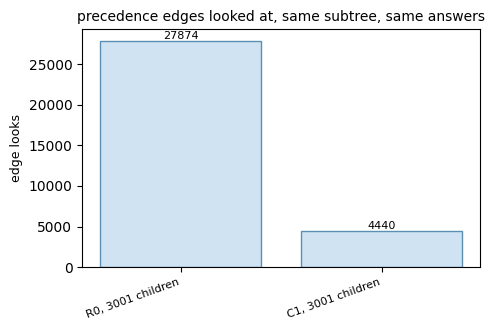

In [15]:
def walk(limit):
    '''Depth-first over the time decisions; every child built by R0 and by C1.'''
    looks = [0, 0]
    nodes = 0
    stack = [(root_r0, root_c1)]
    while stack and nodes < limit:
        parent_r0, parent_c1 = stack.pop()
        free = [o for o in question.selected_operations if len(parent_r0[o]) > 1]
        if not free:
            continue
        o = free[0]
        for v in parent_r0[o]:
            CountingEdges.looks = 0
            trial = dict(parent_r0); trial[o] = (v,)
            a = P_r0.times_fixpoint(trial)
            looks[0] += CountingEdges.looks
            CountingEdges.looks = 0
            b = P_c1.time_child(parent_c1, o, v)
            looks[1] += CountingEdges.looks
            assert (a is None) == (b is None) and (a is None or a == b.D), "the two disagree"
            nodes += 1
            if a is not None:
                stack.append((a, b))
    return nodes, looks

rows = []
for limit in (10, 100, 1000, 3000):        # turn the knob: a bigger subtree
    stats_r0.certificates.clear(); stats_c1.certificates.clear()
    nodes, (l0, l1) = walk(limit)
    same = stats_r0.certificates == stats_c1.certificates
    rows.append((limit, nodes, l0, l1))
    print(f"{nodes:>5} children: edge looks R0 {l0:>6}, C1 {l1:>5}  (x{l1 / l0:.2f})   "
          f"identical certificate streams: {same} ({len(stats_r0.certificates)} certificates)")

viz.show_bars([f"R0, {rows[-1][1]} children", f"C1, {rows[-1][1]} children"],
              [rows[-1][2], rows[-1][3]], "precedence edges looked at, same subtree, same answers",
              "edge looks", fmt="{:.0f}")

The same children, the same domains, the same certificates in the same order, for a
fraction of the work. The assertion inside `walk` would stop the cell at the first
disagreement.

## 10.5 The whole compiler, R0 against C1

Now the real thing: both complete compilers, on the logical clock with the same node
limit, on several programs. We compare the **full search trace** (every node and
every decision, hashed), the **certificate stream** and the final answer, and we time
both. The programs are three public ones and three from the generator.

program                          J         trace  certificates    R0 s   C1 s  C1/R0


02_scalar_dual_chain     24 -> 24    a1bc8860c4b3  5ee080644949    0.12   0.06  0.49


05_mixed_broadcast      240 -> 144   9df584981215  c7203e6048aa    0.54   0.37  0.68


08_vector_reduction     480 -> 384   bb47285c1f50  aae20413401a    2.74   1.13  0.41


generated 980001        440 -> 288   9cb5d1db674e  cfeaa1249216    0.93   0.40  0.43
generated 980026       1840 -> 1440  742f8ab94808  781292275c5a    0.13   0.07  0.53


generated 980183        968 -> 726   a15112743edc  986286e279fb    0.06   0.05  0.85


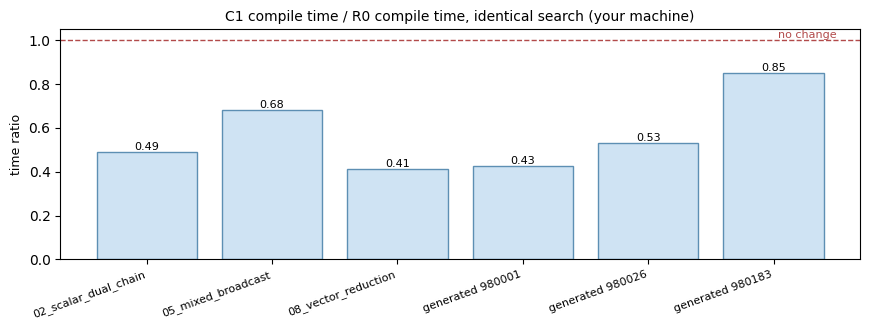

In [16]:
def first_answer(prog):
    f = dc.derive(prog)
    compiled, _ = dcomp.compile_with_report(prog, dcomp.DEFAULT_LIMITS, optimise=False)
    return prog, f, se.issue_cycles_of(prog, compiled["bundles"]), dict(compiled["scratch"])

suite = {name: machine.load_program(ROOT / f".reference/programs/{name}.json")
         for name in ("02_scalar_dual_chain", "05_mixed_broadcast", "08_vector_reduction")}
for seed in (980001, 980026, 980183):
    suite[f"generated {seed}"] = gp.additional_program(seed)

digest = lambda obj: hashlib.sha256(repr(obj).encode()).hexdigest()[:12]
speed = []
print(f"{'program':22} {'J':>11}  {'trace':>12} {'certificates':>13}  {'R0 s':>6} {'C1 s':>6}  C1/R0")
for name, prog in suite.items():
    start = first_answer(prog)
    outcome = {}
    for arm, module in (("R0", r0), ("C1", c1)):
        trace = []
        t, a, rec, secs = run(module, *start, trace=trace)
        outcome[arm] = (se.objective(start[1], t, a)[2], digest(trace),
                        rec["propagation"]["certificate_stream_sha256"][:12], secs)
    assert outcome["R0"][:3] == outcome["C1"][:3], name     # same J, same trace, same certificates
    j, tr, ce, _ = outcome["R0"]
    j_first = se.objective(start[1], start[2], start[3])[2]
    ratio = outcome["C1"][3] / outcome["R0"][3]
    speed.append((name, ratio))
    print(f"{name:22} {j_first:>4} -> {j:<4}  {tr:>12} {ce:>13}  "
          f"{outcome['R0'][3]:6.2f} {outcome['C1'][3]:6.2f}  {ratio:.2f}")

viz.show_bars([n for n, _ in speed], [r for _, r in speed],
              "C1 compile time / R0 compile time, identical search (your machine)",
              "time ratio", reference=("no change", 1.0), fmt="{:.2f}")

The hashes are equal row by row: C1 walks the same tree, makes the same decisions,
emits the same proofs and returns the same compilation as R0, only faster. The
saving is largest where the search is largest, as §10.4 predicts: a child saves a
fixed fraction of a node's work, so the more nodes, the more saved. (The seconds
are yours; the equality of the hashes is not a matter of timing.)

---

# 11. A caution that the paper must state: under a real clock, speed changes the path

§10 used the logical clock, on which slices end by node count. The submitted compiler
runs on the **real** clock, where each question's turn lasts 2 ms. C1 expands more
nodes in 2 ms than R0 does, so a *different* question can be the first to find an
improvement. The first improvement wins its epoch, so the search can then follow a
different path, and a different path can end at a **worse** local optimum.

Here is the clearest case measured on the fresh cohort, program 980183, at a 1 s
budget. *(This cell depends on your machine's speed; on the measurement machine the
outcome was the same in all five repetitions.)*

In [17]:
start = first_answer(gp.additional_program(980183))
print("first answer J =", se.objective(start[1], start[2], start[3])[2], "\n")
for arm, module in (("R0", r0), ("C1", c1)):
    t, a, rec = module.multiscale_optimise(*start, budget_seconds=1.0, catalog="a4", traversal="dfs")
    print(f"{arm}: J = {se.objective(start[1], t, a)[2]:4}, {rec['aggregate']['nodes']:4} nodes, "
          f"{rec['epochs']} epochs, finished in {rec['seconds']:.2f} s")
    for step in rec["improvements"][:3]:
        print(f"      epoch {step['epoch']}: {step['from_CS']} -> {step['to_CS']}  via {step['policy']}")

first answer J = 968 

R0: J =  726,  354 nodes, 8 epochs, finished in 0.11 s
      epoch 1: [22, 44] -> [22, 43]  via k8_memory
      epoch 2: [22, 43] -> [22, 42]  via windows_for
      epoch 3: [22, 42] -> [22, 41]  via windows_for
C1: J =  924,  162 nodes, 3 epochs, finished in 0.04 s
      epoch 1: [22, 44] -> [22, 43]  via k16_memory
      epoch 2: [22, 43] -> [22, 42]  via windows_for


Both runs finish well inside their second. In the first epoch, R0's `k8_memory`
question found an improvement first; C1, being faster, let its `k16_memory` question
get further in its first turns, and that one won instead. From there the two
searches diverge, and C1 stops at a worse J.

This is a property of the controller (first improvement over time slices), not an
error in C1. It means two things for any claim:

- **"Identical decisions" holds at equal work**, which is what §10 and the fixed-work
  measurement test. Under a wall-clock budget it does not hold program by program.
- The quality claim is **distributional**: over 200 fresh programs, C1 is better on
  some, worse on a few, equal on most (§12).

---

# 12. What was measured

The confirmation used **200 fresh programs** (seeds 980000 to 980199, 40 per family),
generated only after C1 had been frozen, each compiled 5 times by each arm in a fresh
process. Two endpoints were registered in advance, with 97.5% intervals from a
bootstrap over programs within families:

- **cost**: complete compile-call time at identical work (10,000 nodes, logical
  clock), C1 / R0; the upper bound had to be at most 0.80;
- **quality**: J at the real 0.1 s budget, C1 / R0; the upper bound had to be at most
  1.01 (i.e. "not worse").

verdict: SUCCESS    programs: 200
fixed-work parity: 1000 of 1000 pairs identical
independent recomputation agrees: True   cost 0.5743  quality 0.9908


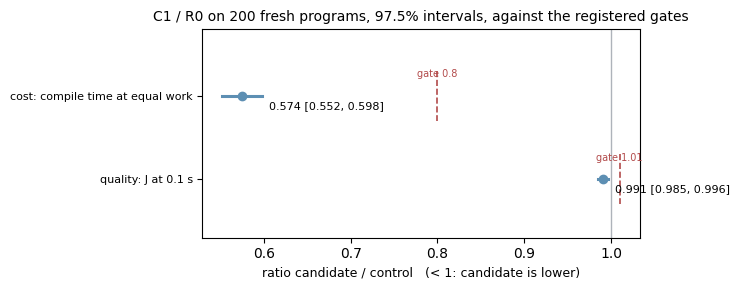

In [18]:
comparison = load(RUN / "COMPARISON.json")
recompute = load(REVIEW / "RECOMPUTE.json")
iv = comparison["intervals_97_5"]
print("verdict:", comparison["verdict"], "   programs:", comparison["programs"])
print("fixed-work parity:", comparison["fixed_work_parity"]["pairs"] - comparison["fixed_work_parity"]["mismatch_count"],
      "of", comparison["fixed_work_parity"]["pairs"], "pairs identical")
print("independent recomputation agrees:", recompute["verdict_reproduced"],
      "  cost", round(recompute["endpoints"]["cost_ratio"], 4), " quality", round(recompute["endpoints"]["quality_ratio"], 4))
viz.show_ratio_intervals(
    [("cost: compile time at equal work", comparison["cost_ratio"], *iv["cost"], 0.80),
     ("quality: J at 0.1 s", comparison["quality_ratio"], *iv["quality"], 1.01)],
    "C1 / R0 on 200 fresh programs, 97.5% intervals, against the registered gates")

Both intervals sit well inside their gates. The review recomputed both endpoints from
the raw rows with separate code and got the same numbers.

## 12.1 Program by program

A single ratio hides the spread. Each dot below is one fresh program: R0's median
compile time at equal work on the horizontal axis, C1's ratio on the vertical.

200 programs; C1 slower on 7; median ratio 0.554


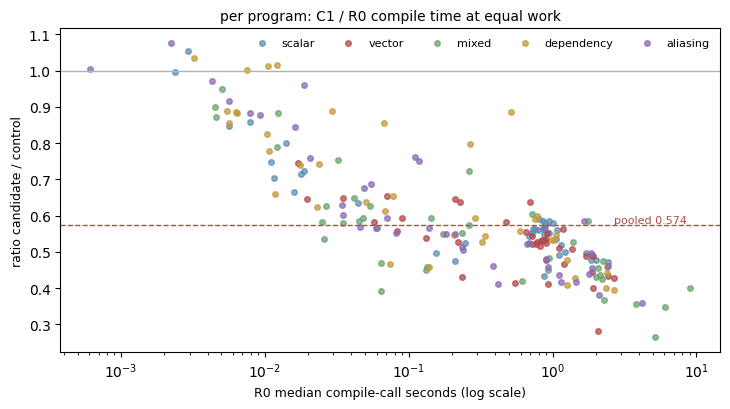

In [19]:
cohort = load(RUN / "cohort/COHORT_CHECKED.json")["programs"]
by = collections.defaultdict(lambda: collections.defaultdict(list))
for line in (RUN / "stages/C_fixed_work/rows.jsonl").read_text().splitlines():
    row = json.loads(line)
    by[row["seed"]][row["arm_id"]].append(row["compile_call_seconds"])
points = []
for seed, arms in by.items():
    base, cand = statistics.median(arms["R0"]), statistics.median(arms["C1"])
    points.append((base, cand / base, cohort[str(seed)]["family"]))
slower = sum(1 for _, r, _ in points if r > 1)
print(f"{len(points)} programs; C1 slower on {slower}; median ratio {statistics.median(r for _, r, _ in points):.3f}")
viz.show_ratio_scatter(points, "per program: C1 / R0 compile time at equal work",
                       "R0 median compile-call seconds (log scale)",
                       reference=(f"pooled {comparison['cost_ratio']:.3f}", comparison["cost_ratio"]))

The pattern matches the mechanism. On tiny programs there is little search to save,
and fixed costs (building the first answer, validating) dominate, so ratios sit
nearer 1. As the search grows, ratios fall towards one half and below. A handful of
very small programs are slightly slower with C1.

## 12.2 Quality, and the public programs

In [20]:
d = comparison["descriptive"]
for budget in ("wall:0.01", "wall:0.1", "wall:1.0"):
    wins, ties, losses = d[f"{budget}_W_T_L_C1"]
    print(f"{budget:9}  J ratio {d[f'{budget}_J_ratio_geo']:.4f}   C1 better {wins:3}, equal {ties:3}, worse {losses:2}  "
          f"(of 1,000 paired runs)")
print("\npublic score (8 programs; higher is better; the serial compiler scores 1):")
for key, scores in d["public_scores"].items():
    print(f"  {key:14} {scores[0]:.4f}")

wall:0.01  J ratio 0.9858   C1 better 150, equal 850, worse  0  (of 1,000 paired runs)
wall:0.1   J ratio 0.9908   C1 better 123, equal 871, worse  6  (of 1,000 paired runs)
wall:1.0   J ratio 0.9972   C1 better  36, equal 947, worse 17  (of 1,000 paired runs)

public score (8 programs; higher is better; the serial compiler scores 1):
  C1@wall:0.01   2.1353
  C1@wall:0.1    2.1880
  C1@wall:1.0    2.1880
  R0@wall:0.01   2.0810
  R0@wall:0.1    2.1880
  R0@wall:1.0    2.1880


At every budget C1 is better in more runs than it is worse. The losses at 1 s are the
path effect of §11. On the eight public programs both compilers already find the same
answers at 0.1 s and 1 s; at 0.01 s C1's speed turns into a better score, because
within that very short budget it completes more of the search.

---

# 13. The file that is submitted

The deliverable is a single self-contained `compiler.py`, exported from C1 and
checked byte for byte against its manifest. It is run exactly as the challenge runs a
compiler: a program file in, compilation JSON out. The challenge's validator then
checks it.

In [21]:
export = RUN / "exports/C1/compiler.py"
print("export sha256:", sha(export)[:16], "  manifest says:",
      load(RUN / "exports/C1/compiler_MANIFEST.json")["export_sha256"][:16])
target = ROOT / ".reference/programs/05_mixed_broadcast.json"
done = subprocess.run([sys.executable, str(export), str(target)], capture_output=True, text=True,
                      cwd=str(ROOT), env={"PYTHONPATH": f"{ROOT / '.reference'}"}, timeout=120)
compiled = json.loads(done.stdout)
cycles = machine.check_compilation(program, compiled)
for case in program["cases"]:
    machine.check_case(program, compiled, case)
footprint = machine.scratch_footprint(program, compiled)
print(f"exported C1 on 05_mixed_broadcast: C = {cycles}, S = {footprint}, J = {cycles * footprint}, "
      f"all {len(program['cases'])} cases correct")

export sha256: 58ee75059dcbdd9f   manifest says: 58ee75059dcbdd9f


exported C1 on 05_mixed_broadcast: C = 9, S = 16, J = 144, all 2 cases correct


---

# 14. Summary

**The final approach, in one paragraph.** C1 builds a first answer entirely from exact
index-set queries: each issue cycle and each address is the smallest member of a set
described by cubes. It then improves that answer by large-neighbourhood search. It
reopens related groups of decisions, confines each question to the region where a
strict improvement of J = C × S could lie, deletes impossible options by sound
propagation with a checkable certificate for every deletion, and searches the rest
exactly. It keeps the first validated improvement and starts again from it. Its one
new idea is the shared branch state: every search node keeps the facts it derived, so
a child re-examines only what its single decision could have changed. This makes the
same search, with the same decisions and the same proofs, about 1.7 times faster.

**What the evidence supports**

| claim | evidence |
|---|---|
| C1 decides exactly as R0 at equal work | 1,000/1,000 fresh pairs; exhaustive fixtures; 53 inherited tests; §10 here |
| C1 is faster at equal work | cost ratio 0.574 [0.552, 0.598] on 200 fresh programs (§12) |
| C1's output is not worse at 0.1 s | J ratio 0.991 [0.985, 0.996] (§12) |
| the index method beats the serial and classical compilers on output quality | public score, notebook 03 §7 and §12 here |

**What it does not support**

- **Not better on every program.** Under a real clock, speed changes the search path
  (§11).
- **Not faster than classical compilation.** Classical compilation remains far
  quicker to compile. The gain here is within our own method.
- **Not a complexity result.** The speed-up belongs to this Python implementation,
  on one local machine.
- **No private-grader result.** The public programs were visible during
  development.
- **Memory.** C1 uses somewhat more working memory than R0 (peak ratio median 1.05,
  maximum 1.30), measured on development programs only.
- **Self-review.** The acceptance was a self-review, disclosed as such in `REVIEW.md`.

**Where to go deeper**

| topic | notebook |
|---|---|
| cycles, engines, latency, scratch, the validator | 00 |
| cubes, covers and the first answer | 01 |
| the decision encoding and depth-first search | 02 |
| the solver ladder A1 to A4, the catalogue and the learning experiments | 03 |